##  Sales Performance Analysis

In [125]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [127]:
data = pd.read_csv('C:/Users/Chet/Documents/sales.csv')  
data

,OrderID,OrderDate,Region,Salesperson,ProductName,Sales
0,1001,2023-01-01,East,Alice,Laptop,1200
1,1002,2023-01-16,West,Bob,Tablet,800
2,1003,2023-01-31,North,Charlie,Monitor,450
3,1004,2023-02-15,South,David,Printer,700
4,1005,2023-03-02,East,Eve,Laptop,1300
5,1006,2023-03-17,West,Frank,Monitor,470
6,1007,2023-04-01,North,Grace,Tablet,820
7,1008,2023-04-16,South,Heidi,Printer,750
8,1009,2023-05-01,East,Ivan,Laptop,1100
9,1010,2023-05-16,West,Judy,Monitor,490


In [129]:
data['OrderDate'] = pd.to_datetime(data['OrderDate'])

print(data.head())

   OrderID  OrderDate Region Salesperson ProductName  Sales
0     1001 2023-01-01   East       Alice      Laptop   1200
1     1002 2023-01-16   West         Bob      Tablet    800
2     1003 2023-01-31  North     Charlie     Monitor    450
3     1004 2023-02-15  South       David     Printer    700
4     1005 2023-03-02   East         Eve      Laptop   1300


In [131]:
data['YearMonth'] = data['OrderDate'].dt.to_period('M')

# Top products by sales
top_products = data.groupby('ProductName')['Sales'].sum().sort_values(ascending=False)
print("Top products by total sales:")
print(top_products)

# Monthly sales trend
monthly_sales = data.groupby('YearMonth')['Sales'].sum()
print("\nMonthly sales trend:")
print(monthly_sales)

# Regional sales summary
regional_sales = data.groupby('Region')['Sales'].sum()
print("\nSales by region:")
print(regional_sales)


Top products by total sales:
ProductName
Laptop     3600
Tablet     1620
Printer    1450
Monitor    1410
Name: Sales, dtype: int64

Monthly sales trend:
YearMonth
2023-01    2450
2023-02     700
2023-03    1770
2023-04    1570
2023-05    1590
Freq: M, Name: Sales, dtype: int64

Sales by region:
Region
East     3600
North    1270
South    1450
West     1760
Name: Sales, dtype: int64


In [133]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')


## 1. Bar plot - Top Products by Sales

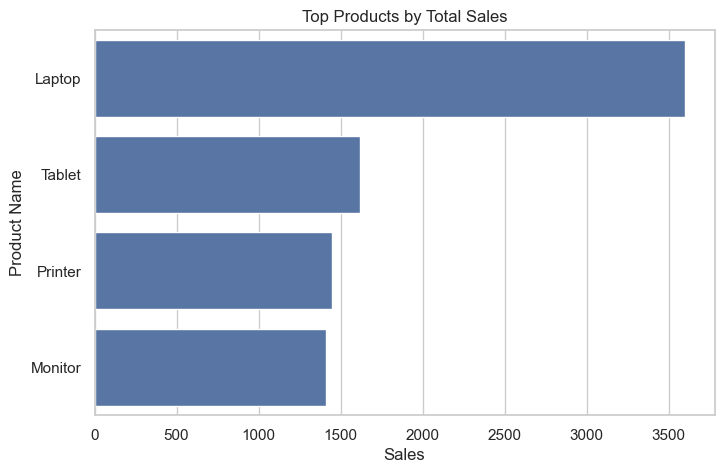

In [136]:
plt.figure(figsize=(8,5))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title('Top Products by Total Sales')
plt.xlabel('Sales')
plt.ylabel('Product Name')
plt.show()

## 2. Line plot - Monthly Sales Trend


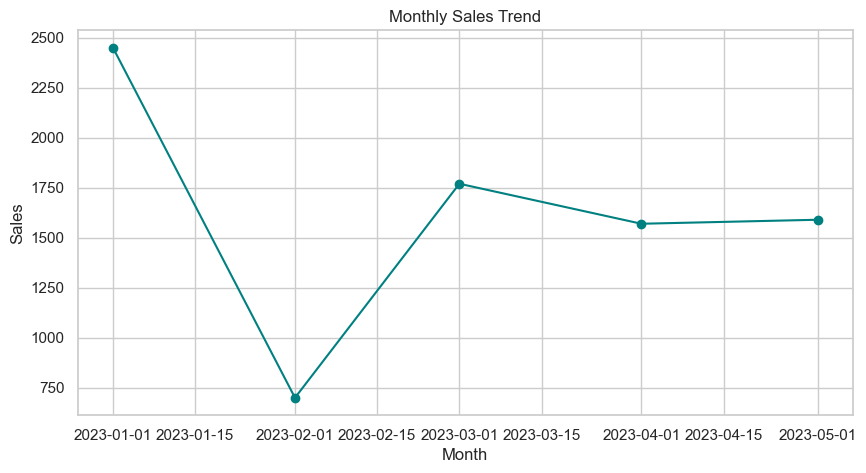

In [139]:
monthly_sales.index = monthly_sales.index.to_timestamp() 
plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linestyle='-', color='teal')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.grid(True)
plt.show()


## 3. Bar plot - Sales by Region

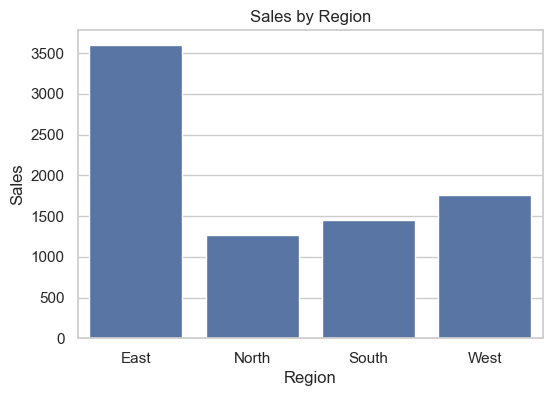

In [142]:

plt.figure(figsize=(6,4))
sns.barplot(x=regional_sales.index, y=regional_sales.values)
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.show()

